In [1]:
# 1 — Rebuild the waiting-time base (same rules and 10 terminals as notebooks 07 and 10)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()
calls["wait_h"] = (calls["ts_berth"] - calls["ts_arrival"]).dt.total_seconds() / 3600
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
calls["file_year_start"] = pd.to_datetime(calls["year"].astype(str) + "-01-01")

lc = calls[calls["navigation"] == "Longo Curso"]
w = lc[lc["ts_arrival"].between("2024-01-01", "2025-12-14 23:59")].copy()
w["arr_year"] = w["ts_arrival"].dt.year
w["month_p"] = w["ts_arrival"].dt.to_period("M")

prof = w.groupby(["terminal", "arr_year"]).agg(
    n=("call_id", "size"), teu=("teu", "mean"), p50=("wait_h", "median"),
    p90=("wait_h", lambda s: s.quantile(0.9)), below_1h=("wait_h", lambda s: (s < 1).mean())).unstack("arr_year")
ok = lambda y: (prof[("n", y)] >= 100) & (prof[("teu", y)] >= 300) & (prof[("below_1h", y)] <= 0.5) \
               & (prof[("p90", y)] / prof[("p50", y)] >= 2)
TERMINALS = prof.index[ok(2024) & ok(2025)].tolist()

uni = w[w["terminal"].isin(TERMINALS)].copy()
monthly = uni.groupby(["terminal", "month_p"]).size().unstack(fill_value=0).astype(float)
dec25 = pd.Period("2025-12", "M")
monthly[dec25] = monthly[dec25] * 31 / 14
low = monthly.lt(0.5 * monthly.drop(columns=[dec25]).median(axis=1), axis=0)
GAP_MONTHS = {(t, m) for t in low.index for m in low.columns if low.loc[t, m]}

mdf = uni[[(t, m) not in GAP_MONTHS for t, m in zip(uni["terminal"], uni["month_p"])]]
mdf = mdf[mdf["wait_h"].between(0, 14 * 24)
          & (mdf["ts_arrival"] >= mdf["file_year_start"] - pd.Timedelta(days=31))].copy()
mdf["month"] = mdf["ts_arrival"].dt.month

src = calls.dropna(subset=["ts_arrival", "ts_berth", "ts_unberth"])
src = src[(src["ts_arrival"] >= "2023-12-01") & src["wait_h"].between(0, 30 * 24)]
parts = []
for t, b in mdf.groupby("terminal"):
    s = src[src["terminal"] == t]
    t0 = b["ts_arrival"].values[:, None]
    arr, ber, unb = (s[c].values[None, :] for c in ["ts_arrival", "ts_berth", "ts_unberth"])
    parts.append(pd.DataFrame({"call_id": b["call_id"].values,
                               "q_waiting": ((arr < t0) & (ber > t0)).sum(axis=1),
                               "q_at_berth": ((ber <= t0) & (unb > t0)).sum(axis=1)}))
mdf = mdf.merge(pd.concat(parts), on="call_id", validate="1:1")

print(f"Terminals: {len(TERMINALS)} | calls by arrival year: {mdf['arr_year'].value_counts().sort_index().to_dict()}")
print("Median wait (h):", mdf.groupby("arr_year")["wait_h"].median().round(1).to_dict())
print("Excluded low-activity months:", sorted((t.split(' | ')[0][:18], str(m)) for t, m in GAP_MONTHS))

Terminals: 10 | calls by arrival year: {2024: 4227, 2025: 4389}
Median wait (h): {2024: 17.6, 2025: 15.2}
Excluded low-activity months: [('Salvador', '2025-08'), ('Salvador', '2025-12'), ('Terminal Portuário', '2024-05'), ('Terminal Portuário', '2024-06')]


In [2]:
# 2 — Daily berth occupancy for the 10 terminals, with a consistency check
RAW = BASE / "data" / "raw"
MONTHS = {"jan": 1, "fev": 2, "mar": 3, "abr": 4, "mai": 5, "jun": 6,
          "jul": 7, "ago": 8, "set": 9, "out": 10, "nov": 11, "dez": 12}

occ = pd.concat([pd.read_csv(RAW / f"antaq_{y}_taxa_ocupacao.txt", sep=";", encoding="utf-8-sig", dtype=str)
                 for y in (2024, 2025)], ignore_index=True)
occ.columns = ["berth", "day", "month", "year", "minutes"]
occ["date"] = pd.to_datetime(pd.DataFrame({"year": occ["year"].astype(int),
                                           "month": occ["month"].str.lower().map(MONTHS),
                                           "day": occ["day"].astype(int)}))
occ["year"] = occ["year"].astype(int)
occ["minutes"] = pd.to_numeric(occ["minutes"], errors="coerce")

atr = pd.concat([pd.read_csv(RAW / f"antaq_{y}_atracacao.txt", sep=";", encoding="utf-8-sig", dtype=str,
                             usecols=["IDAtracacao", "IDBerco", "Porto Atracação", "Terminal",
                                      "Data Atracação", "Data Desatracação"]) for y in (2024, 2025)],
                ignore_index=True)
atr["terminal"] = atr["Porto Atracação"].str.strip() + " | " + atr["Terminal"].fillna("").str.strip()
atr["is_container"] = atr["IDAtracacao"].astype(int).isin(set(calls["call_id"]))
for c in ["Data Atracação", "Data Desatracação"]:
    atr[c] = pd.to_datetime(atr[c], format="%d/%m/%Y %H:%M:%S", errors="coerce")

bt = (atr[atr["is_container"] & atr["terminal"].isin(TERMINALS)]
      .groupby(["IDBerco", "terminal"]).size().rename("container_calls").reset_index())
bt = bt[bt["container_calls"] >= 20].sort_values("container_calls", ascending=False).drop_duplicates("IDBerco")
BERTH_TO_T = dict(zip(bt["IDBerco"], bt["terminal"]))
short = lambda t: t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:16]

on_berths = atr[atr["IDBerco"].isin(BERTH_TO_T)]
berth_info = bt.set_index("IDBerco").assign(
    container_share_pct=100 * on_berths.groupby("IDBerco")["is_container"].mean())
print("Berths per terminal and share of their calls that are container ships:")
print(berth_info.groupby("terminal").agg(berths=("container_calls", "size"),
                                         container_share_pct=("container_share_pct", "mean"))
      .rename(index=short).round(0).to_string(), "\n")

on_berths = on_berths.assign(berth_min=(on_berths["Data Desatracação"] - on_berths["Data Atracação"])
                             .dt.total_seconds() / 60, year=on_berths["Data Atracação"].dt.year)
own = on_berths.groupby(["IDBerco", "year"])["berth_min"].sum()
ant = occ[occ["berth"].isin(BERTH_TO_T)].groupby(["berth", "year"])["minutes"].sum()
ant.index = ant.index.set_names(["IDBerco", "year"])
chk = pd.concat([own.rename("from_calls"), ant.rename("antaq_occupancy")], axis=1).dropna()
chk["ratio"] = chk["antaq_occupancy"] / chk["from_calls"]
print(f"Consistency, ANTAQ occupancy minutes / berth time of the calls (berth-years: {len(chk)}): "
      f"median {chk['ratio'].median():.3f}, P10 {chk['ratio'].quantile(0.1):.3f}, P90 {chk['ratio'].quantile(0.9):.3f}\n")

o = occ[occ["berth"].isin(BERTH_TO_T)].assign(terminal=lambda d: d["berth"].map(BERTH_TO_T))
daily = o.groupby(["terminal", "date"]).agg(minutes=("minutes", "sum"), berths=("berth", "nunique"))
daily["occupancy"] = daily["minutes"] / (daily["berths"] * 1440)
daily = daily.reset_index()
daily["year"] = daily["date"].dt.year

summ = daily.groupby(["terminal", "year"]).agg(
    mean_occupancy_pct=("occupancy", lambda s: 100 * s.mean()),
    days_above_85pct=("occupancy", lambda s: 100 * (s > 0.85).mean()),
    berths=("berths", "max")).unstack("year")
print("Berth occupancy by terminal and year:")
print(summ.rename(index=short).round(1).to_string())

Berths per terminal and share of their calls that are container ships:
                                       berths  container_share_pct
terminal                                                          
DP World Santos | DP World Santos           3                 79.0
Paranaguá | CAIS PÚBLICO                    2                 57.0
Paranaguá | TCP                             2                100.0
Porto Itapoá Termi | Porto Itapoá Ter       2                100.0
Portonave - Termin | Portonave - Term       2                100.0
Rio Grande | Cais Tecon Rio G               3                100.0
Salvador | TECON Área 2                     1                 99.0
Santos | Cais da BTP (SSZ                   3                 91.0
Santos | Cais da Santos B                   4                 98.0
Terminal Portuário | Terminal Portuár       2                100.0 

Consistency, ANTAQ occupancy minutes / berth time of the calls (berth-years: 48): median 1.000, P10 0.945, P90 1.005

Berth

In [3]:
# 3 — Within each terminal: does waiting rise with occupancy? And what happens in August?
daily["ym"] = daily["date"].dt.to_period("M")
mo = daily.groupby(["terminal", "ym"])["occupancy"].mean().rename("occupancy")
mw = mdf.groupby(["terminal", "month_p"])["wait_h"].median().rename("median_wait_h")
mw.index = mw.index.set_names(["terminal", "ym"])
jm = pd.concat([mo, mw], axis=1).dropna()
rho = jm.groupby(level=0).apply(lambda g: pd.Series({
    "months": len(g), "spearman_occupancy_vs_wait": g["occupancy"].corr(g["median_wait_h"], method="spearman"),
    "occupancy_range_pct": f"{100 * g['occupancy'].min():.0f}-{100 * g['occupancy'].max():.0f}"}))
print("Monthly occupancy vs monthly median wait, by terminal:")
print(rho.rename(index=short).sort_values("spearman_occupancy_vs_wait", ascending=False).round(2).to_string(), "\n")

occ_day = daily.set_index(["terminal", "date"])["occupancy"]
mdf["occ_on_arrival"] = [occ_day.get((t, d), np.nan) for t, d in zip(mdf["terminal"], mdf["ts_arrival"].dt.normalize())]
mdf["log_w"] = np.log1p(mdf["wait_h"])
mdf["excess_ty"] = mdf["log_w"] - mdf.groupby(["terminal", "arr_year"])["log_w"].transform("median")
mdf["occ_band"] = pd.cut(mdf["occ_on_arrival"], [0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01],
                         labels=["<50%", "50-60%", "60-70%", "70-80%", "80-90%", ">=90%"], include_lowest=True)
cb = mdf.groupby("occ_band", observed=True).agg(calls=("call_id", "size"), median_wait_h=("wait_h", "median"),
                                                excess=("excess_ty", "median"))
cb["vs_same_terminal_year_%"] = 100 * (np.exp(cb.pop("excess")) - 1)
print("Wait by terminal occupancy on the day of arrival (all 10 terminals):")
print(cb.round(1).to_string(), "\n")

big = ["Paranaguá | TCP", "Porto Itapoá Terminais Portuários | Porto Itapoá Terminais Portuários"]
big += [t for t in TERMINALS if "Santos" in t]
tb = (mdf[mdf["terminal"].isin(big)].groupby(["terminal", "occ_band"], observed=True)["excess_ty"]
      .median().unstack("occ_band"))
print("Main terminals — wait vs the same terminal and year, by occupancy on arrival (%):")
print((100 * (np.exp(tb) - 1)).rename(index=short).round(0).to_string(), "\n")

daily["is_aug"] = daily["date"].dt.month == 8
mdf["is_aug"] = mdf["month"] == 8
ao = daily.groupby(["terminal", "year", "is_aug"])["occupancy"].mean().unstack("is_aug") * 100
aw = mdf.groupby(["terminal", "arr_year", "is_aug"])["wait_h"].median().unstack("is_aug")
aw.index = aw.index.set_names(["terminal", "year"])
aug = pd.DataFrame({"occ_other_%": ao[False], "occ_august_%": ao[True],
                    "wait_other_h": aw[False], "wait_august_h": aw[True]})
print("August vs the rest of the year — occupancy and median wait:")
print(aug.rename(index=short, level=0).round(1).to_string())

Monthly occupancy vs monthly median wait, by terminal:
                                       months  spearman_occupancy_vs_wait occupancy_range_pct
terminal                                                                                     
Paranaguá | TCP                            24                        0.79               74-93
Rio Grande | Cais Tecon Rio G              24                        0.78               36-71
Terminal Portuário | Terminal Portuár      22                        0.73               26-56
Santos | Cais da Santos B                  24                        0.71               60-84
Paranaguá | CAIS PÚBLICO                   24                        0.64               26-57
Portonave - Termin | Portonave - Term      24                        0.64               30-44
DP World Santos | DP World Santos          24                        0.57               67-82
Santos | Cais da BTP (SSZ                  24                        0.29               57-85
Porto

In [4]:
# 4 — August at the busiest terminals: more arrivals, longer stays or more stoppages?
par = pd.concat([pd.read_csv(RAW / f"antaq_{y}_paralisacoes.txt", sep=";", encoding="utf-8-sig", dtype=str)
                 for y in (2024, 2025)], ignore_index=True)
par["call_id"] = par["IDAtracacao"].astype(int)
for c in ["DTInicio", "DTTermino"]:
    par[c] = pd.to_datetime(par[c].str[:19], format="%Y-%m-%d %H:%M:%S", errors="coerce")
par["hours"] = (par["DTTermino"] - par["DTInicio"]).dt.total_seconds() / 3600
d_ = par["DescricaoTempoDesconto"].fillna("")
par["cause"] = np.select(
    [d_.str.contains("Chuva|clim", case=False), d_.str.contains("Maré", case=False),
     d_.str.contains("Quebra|energia", case=False), d_.str.contains("Aguardando carga|rodovi|vagões", case=False)],
    ["weather", "tide", "equipment", "cargo/land transport"], default="other")

stop = (par[par["call_id"].isin(mdf["call_id"]) & par["hours"].between(0, 240)]
        .groupby(["call_id", "cause"])["hours"].sum().unstack("cause").fillna(0))
mdf2 = mdf.merge(stop, left_on="call_id", right_index=True, how="left")
causes = [c for c in ["weather", "tide", "equipment", "cargo/land transport", "other"] if c in mdf2.columns]
mdf2[causes] = mdf2[causes].fillna(0)
mdf2["berth_h"] = (mdf2["ts_unberth"] - mdf2["ts_berth"]).dt.total_seconds() / 3600

BUSY = [t for t in TERMINALS if ("Santos" in t) or ("Paranaguá" in t) or ("Itapoá" in t)]
days_in_year = {2024: 366, 2025: 348}          # 2025 window ends on 14 December
rows = []
for (t, y), g in mdf2[mdf2["terminal"].isin(BUSY)].groupby(["terminal", "arr_year"]):
    for aug, gg in g.groupby("is_aug"):
        n_days = 31 if aug else days_in_year[y] - 31
        r = {"terminal": short(t), "year": y, "period": "August" if aug else "other months",
             "arrivals_per_week": 7 * len(gg) / n_days, "median_berth_h": gg["berth_h"].median()}
        r.update({f"stop_{c}_h": gg[c].mean() for c in causes})
        rows.append(r)
res = pd.DataFrame(rows).set_index(["terminal", "year", "period"])
print("Busiest terminals — August vs other months (stoppage hours = mean per call):")
print(res.round(1).to_string())
print(f"\nTerminals with no stoppages recorded at all: "
      f"{[short(t) for t in TERMINALS if mdf2.loc[mdf2['terminal'] == t, causes].to_numpy().sum() == 0]}")

Busiest terminals — August vs other months (stoppage hours = mean per call):
                                                         arrivals_per_week  median_berth_h  stop_weather_h  stop_tide_h  stop_equipment_h  stop_cargo/land transport_h  stop_other_h
terminal                              year period                                                                                                                                   
DP World Santos | DP World Santos     2024 other months                9.4            26.0             0.0          0.0               0.0                          0.0           0.0
                                           August                      7.9            30.0             0.0          0.0               0.0                          0.0           0.0
                                      2025 other months                8.8            23.6             0.0          0.0               0.0                          0.0           0.0
                  

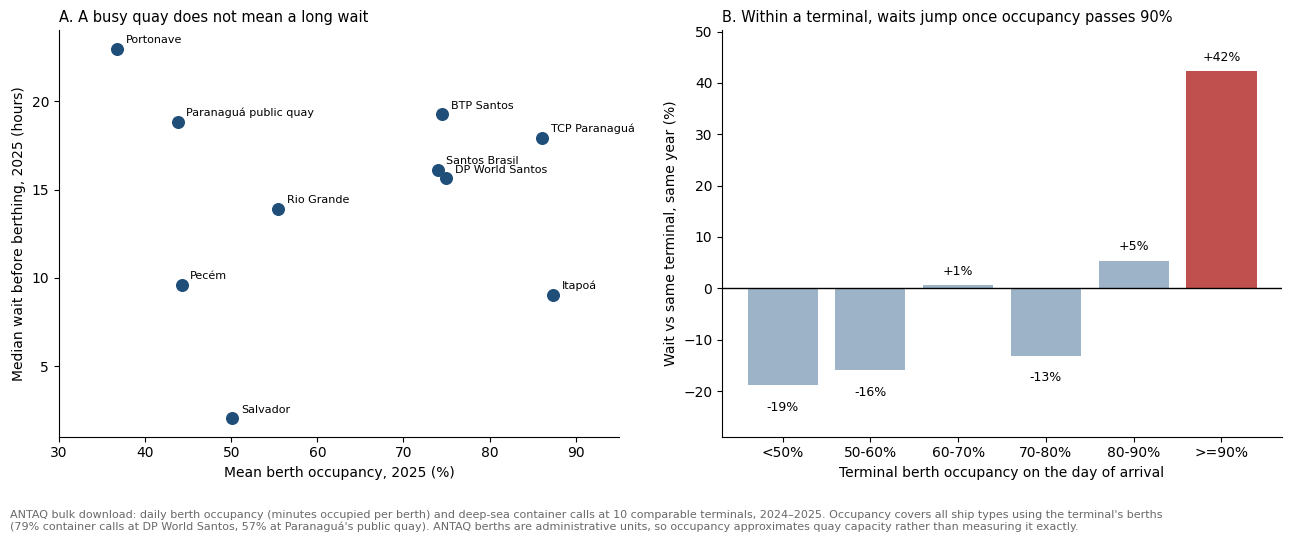

In [5]:
# 5 — Figure (fig18): occupancy and waiting
FIG_DIR = BASE / "outputs" / "figures"

def label(t):
    for key, name in [("Itapoá", "Itapoá"), ("TCP", "TCP Paranaguá"), ("CAIS PÚBLICO", "Paranaguá public quay"),
                      ("BTP", "BTP Santos"), ("Santos Brasil", "Santos Brasil"), ("DP World", "DP World Santos"),
                      ("Portonave", "Portonave"), ("Rio Grande", "Rio Grande"), ("Salvador", "Salvador"),
                      ("Pecém", "Pecém")]:
        if key in t:
            return name
    return t[:20]

w25 = mdf[mdf["arr_year"] == 2025].groupby("terminal")["wait_h"].median()
o25 = 100 * daily[daily["year"] == 2025].groupby("terminal")["occupancy"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(o25, w25.reindex(o25.index), s=70, color="#1f4e79", zorder=3)
for t in o25.index:
    ax1.annotate(label(t), (o25[t], w25[t]), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax1.set_xlim(30, 95)
ax1.set_xlabel("Mean berth occupancy, 2025 (%)")
ax1.set_ylabel("Median wait before berthing, 2025 (hours)")
ax1.set_title("A. A busy quay does not mean a long wait", loc="left", fontsize=10.5)

vals = cb["vs_same_terminal_year_%"]
ax2.bar(range(len(vals)), vals, color=["#c0504d" if b == ">=90%" else "#9db4c8" for b in vals.index])
for i, v_ in enumerate(vals):
    ax2.text(i, v_ + (2 if v_ >= 0 else -5), f"{v_:+.0f}%", ha="center", fontsize=9)
ax2.axhline(0, color="black", lw=1)
ax2.set_ylim(vals.min() - 10, vals.max() + 8)
ax2.set_xticks(range(len(vals)), list(vals.index))
ax2.set_xlabel("Terminal berth occupancy on the day of arrival")
ax2.set_ylabel("Wait vs same terminal, same year (%)")
ax2.set_title("B. Within a terminal, waits jump once occupancy passes 90%", loc="left", fontsize=10.5)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.07,
         "ANTAQ bulk download: daily berth occupancy (minutes occupied per berth) and deep-sea container calls at 10 comparable "
         "terminals, 2024–2025. Occupancy covers all ship types using the terminal's berths\n(79% container calls at DP World "
         "Santos, 57% at Paranaguá's public quay). ANTAQ berths are administrative units, so occupancy approximates quay "
         "capacity rather than measuring it exactly.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig18_berth_occupancy.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Daily berth occupancy from ANTAQ (minutes each berth is occupied) for the 10 comparable container terminals, 2024–2025, matched to arrival-to-berthing waits. ANTAQ's occupancy minutes equal the berth time of the calls in the call file (median ratio 1.000), so the two sources measure the same thing.

**At what occupancy do waits take off, and which terminals are close to the limit?**

- **Within a terminal, waits barely react below 80–90% occupancy and jump above it.** Ships arriving when their terminal is at 90% or more wait about 42% longer than that terminal's typical wait for the year (+21% at Itapoá to +73% at Santos Brasil).
- **Itapoá and TCP Paranaguá run hottest:** mean occupancy of 86–87% in 2025, above 85% on more than 70% of days.
- **A busy quay does not mean a long wait.** Itapoá has the highest occupancy and one of the shortest waits (about 9 h). Portonave keeps its berths free more than 60% of the time, never passed 85% on any day in two years, and still has one of the longest waits (about 23 h in 2025). Its bottleneck is access, not the quay, consistent with its fast operations (notebook 08).

**Why August? It differs by terminal** (this refines notebook 07):

- **TCP Paranaguá: operations slow down.** Arrivals fall by about 40%, but median berth time rises 30–73% and occupancy reaches 94%. Recorded stoppages do not explain it.
- **Paranaguá public quay: the quay fills with other cargo** at the grain peak (occupancy +15 points), berth time rises about 50%, and tide stoppages add 2–4 hours per call all year.
- **DP World Santos and Itapoá (2024): waits rise with no change in occupancy or berth time,** so the cause lies outside the quay (access, weather or operations not recorded).

**Data quality:** six of the ten terminals (DP World Santos, BTP, Santos Brasil, Portonave, Rio Grande, Pecém) record no stoppages at all in two years, so stoppage causes can only be studied at Paranaguá and Itapoá.

## Limitations

1. **ANTAQ berths are administrative units.** On a continuous quay a large ship can span two berths or two small ships can share one, so occupancy approximates quay capacity.
2. **Occupancy includes all ship types** on the terminal's berths (79% container calls at DP World Santos, 57% at the public quay).
3. **Occupancy and waiting rise together in busy months;** the threshold describes how they move together, not a causal effect of occupancy alone.
4. **Stoppage records are incomplete** at most terminals, so the cause of slower August operations at TCP is not identified.
5. **Two years.**